In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from tqdm import tqdm
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
%ls /content/drive/MyDrive/UPF-BSM/12.RetoIA/All_csv/

500argentino_dataset_features_real.csv
500argentino_dataset_features_sintetico.csv
500chileno_dataset_features_real.csv
500chileno_dataset_features_sintetico.csv
500colombiano_dataset_features_real.csv
500colombiano_dataset_features_sintetico.csv


In [6]:
#Ruta base Sofi
ruta_base = "/content/drive/MyDrive/UPF-BSM/12.RetoIA/All_csv/"

In [ ]:
# Ruta de la carpeta Dany
#ruta_base = "/content/drive/MyDrive/Reto_Telefonica/All_csv/"

In [7]:
# Buscar todos los csv
archivos = glob.glob(ruta_base + "*.csv")

print("CSV encontrados:")
print(archivos)

dfs = []

for archivo in archivos:

    # cargar csv
    df = pd.read_csv(archivo)

    nombre = os.path.basename(archivo).lower()

    # etiqueta
    if "real" in nombre:
        df["label"] = 0
    else:
        df["label"] = 1

    # acento
    if "colombiano" in nombre:
        df["accent"] = "colombiano"

    elif "chileno" in nombre:
        df["accent"] = "chileno"

    elif "argentino" in nombre:
        df["accent"] = "argentino"

    dfs.append(df)

# unir todo
df_unified = pd.concat(dfs, ignore_index=True)

print("\nShape final:")
print(df_unified.shape)

df_unified.head()

CSV encontrados:
['/content/drive/MyDrive/UPF-BSM/12.RetoIA/All_csv/500argentino_dataset_features_sintetico.csv', '/content/drive/MyDrive/UPF-BSM/12.RetoIA/All_csv/500chileno_dataset_features_real.csv', '/content/drive/MyDrive/UPF-BSM/12.RetoIA/All_csv/500chileno_dataset_features_sintetico.csv', '/content/drive/MyDrive/UPF-BSM/12.RetoIA/All_csv/500argentino_dataset_features_real.csv', '/content/drive/MyDrive/UPF-BSM/12.RetoIA/All_csv/500colombiano_dataset_features_sintetico.csv', '/content/drive/MyDrive/UPF-BSM/12.RetoIA/All_csv/500colombiano_dataset_features_real.csv']

Shape final:
(3200, 589)


,id_audio,archivo,label,genero_f,colombiano,chileno,argentino,modelo_cyclegan,modelo_diff,modelo_stargan,...,rolloff_min,rolloff_max,rolloff_median,rolloff_q1,rolloff_q3,rolloff_skew,rolloff_kurtosis,rolloff_mode,rolloff_iqr,accent
0,1,CycleGAN-arf_00295_00101634363-arf_02121_00240...,1,1,0,0,1,1,0,0,...,617.1875,6789.0625,4070.31250,2609.375000,4632.812500,-0.406286,-0.429953,4609.3750,2023.437500,argentino
1,2,CycleGAN-arf_00295_00101634363-arf_02436_01980...,1,1,0,0,1,1,0,0,...,726.5625,6695.3125,3953.12500,2812.500000,4398.437500,-0.416914,-0.086564,4265.6250,1585.937500,argentino
2,3,CycleGAN-arf_00295_00101634363-arf_03397_01066...,1,1,0,0,1,1,0,0,...,632.8125,6875.0000,3160.15625,2103.515625,4179.687500,0.236749,-0.169685,4179.6875,2076.171875,argentino
3,4,CycleGAN-arf_00295_00101634363-arf_05679_01058...,1,1,0,0,1,1,0,0,...,664.0625,6851.5625,3851.56250,2406.250000,4632.812500,-0.168616,-0.592907,3609.3750,2226.562500,argentino
4,5,CycleGAN-arf_00295_00131212768-arf_02121_00863...,1,1,0,0,1,1,0,0,...,1140.6250,7664.0625,4289.06250,2617.187500,4806.640625,-0.007366,-0.499812,4539.0625,2189.453125,argentino


# 1. Exploracion de datos

In [8]:
# Paleta azul y morado
PALETTE = ["#3B82F6", "#800080"]

# Estilo general
sns.set_style("whitegrid")

In [9]:
# Informacion general
print("\nInformacion del dataset:")
df_unified.info()

# Dimensiones del dataset
print("\nShape del dataset:")
print(df_unified.shape)

# Valores nulos
print("\nValores nulos por columna:")
display(df_unified.isnull().sum())

# Estadisticas descriptivas
print("\nEstadisticas descriptivas:")
display(df_unified.describe())

# Variables categoricas
print("\nVariables categoricas:")
display(df_unified.describe(include='object'))

# Valores duplicados
print("\nValores duplicados:")
print(df_unified.duplicated().sum())

# Distribucion de clases
print("\nDistribucion REAL vs IA:")
display(df_unified["label"].value_counts())

# Distribucion por acento
print("\nDistribucion por acento:")
display(df_unified["accent"].value_counts())

# Distribucion cruzada
print("\nDistribucion acento vs label:")
display(pd.crosstab(df_unified["accent"], df_unified["label"]))


Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Columns: 589 entries, id_audio to accent
dtypes: float64(575), int64(12), object(2)
memory usage: 14.4+ MB

Shape del dataset:
(3200, 589)

Valores nulos por columna:


,0
id_audio,0
archivo,0
label,0
genero_f,0
colombiano,0
...,...
rolloff_skew,0
rolloff_kurtosis,0
rolloff_mode,0
rolloff_iqr,0



Estadisticas descriptivas:


,id_audio,label,genero_f,colombiano,chileno,argentino,modelo_cyclegan,modelo_diff,modelo_stargan,modelo_tts_dif,...,rolloff_std,rolloff_min,rolloff_max,rolloff_median,rolloff_q1,rolloff_q3,rolloff_skew,rolloff_kurtosis,rolloff_mode,rolloff_iqr
count,3200.000000,3200.00000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,...,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000
mean,269.250000,0.46875,0.477812,0.312500,0.343750,0.343750,0.084375,0.150000,0.084375,0.037500,...,1763.095087,520.366211,7040.998535,3866.386719,2220.145264,5162.451782,-0.033317,-0.904761,3245.268555,2942.306519
std,157.684678,0.49910,0.499586,0.463585,0.475033,0.475033,0.277993,0.357127,0.277993,0.190013,...,248.521233,345.709845,430.083426,1025.064061,660.144369,729.993004,0.576731,0.699156,1913.652098,846.750145
min,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,951.699335,85.937500,4328.125000,906.250000,501.953125,2121.093750,-2.118632,-1.787087,109.375000,464.843750
25%,134.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1593.994880,195.312500,6835.937500,2968.750000,1789.062500,4796.875000,-0.409374,-1.381745,1531.250000,2439.453125
50%,267.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1767.000355,468.750000,7117.187500,3917.968750,2109.375000,5273.437500,-0.057743,-1.107377,2742.187500,3024.414062
75%,400.250000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1943.256882,742.187500,7335.937500,4687.500000,2519.531250,5679.687500,0.326548,-0.652781,5164.062500,3520.019531
max,600.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,2493.051114,2273.437500,7843.750000,6171.875000,5429.687500,7140.625000,1.853568,3.848599,7515.625000,5162.109375



Variables categoricas:


...

,count
label,
0,1700
1,1500



Distribucion por acento:


,count
accent,
argentino,1100
chileno,1100
colombiano,1000



Distribucion acento vs label:


label,0,1
accent,,
argentino,600,500
chileno,600,500
colombiano,500,500


## 1.1. Distribucion por acento y clase

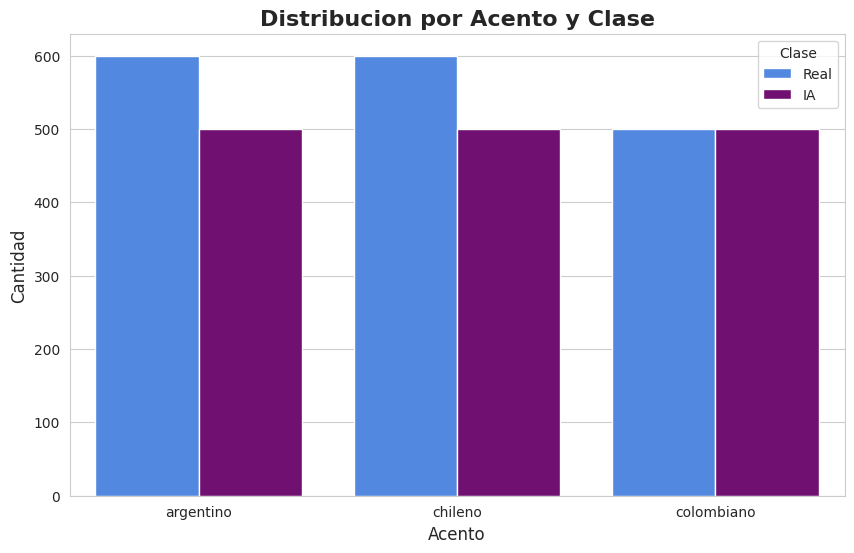

In [10]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df_unified,
    x="accent",
    hue="label",
    palette=PALETTE
)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Real", "IA"], title="Clase")

plt.title("Distribucion por Acento y Clase", fontsize=16, fontweight="bold")
plt.xlabel("Acento", fontsize=12)
plt.ylabel("Cantidad", fontsize=12)

plt.show()

## 1.2. Histograma RMS

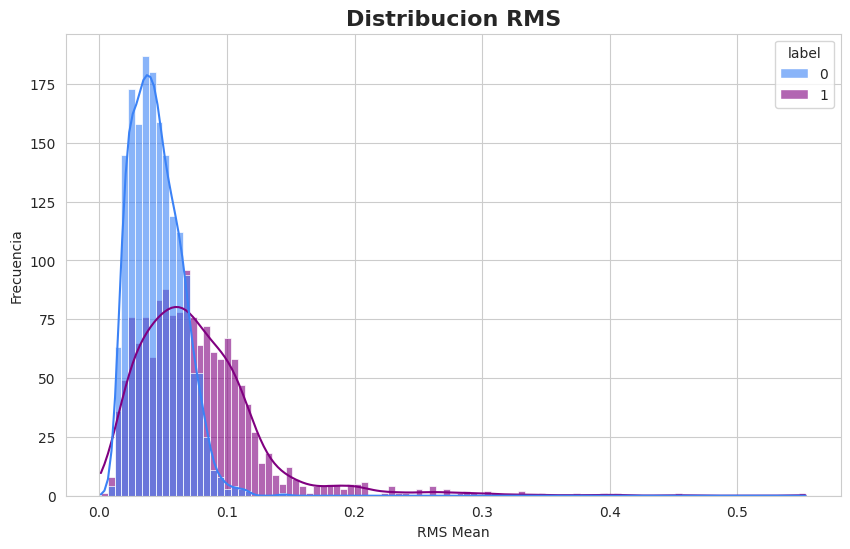

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_unified,
    x="rms_mean",
    hue="label",
    kde=True,
    palette=PALETTE,
    alpha=0.6
)

plt.title("Distribucion RMS", fontsize=16, fontweight="bold")
plt.xlabel("RMS Mean")
plt.ylabel("Frecuencia")

plt.show()

La gráfica analiza la distribución de RMS Mean, una feature que mide la energía promedio del audio. Esta característica es importante porque las voces sintéticas suelen tener patrones de intensidad más uniformes, mientras que las voces reales presentan variaciones naturales en volumen y entonación.
En los resultados se observa que los audios reales (0) se concentran en valores más bajos y compactos, mientras que los audios generados por IA (1) tienen una distribución más dispersa y alcanzan valores de energía más altos. Esto indica que el RMS puede ayudar a diferenciar ambas clases, aunque existe superposición entre ellas, por lo que debe combinarse con otras features acústicas para lograr una mejor detección.

## 1.3. Histograma ZCR

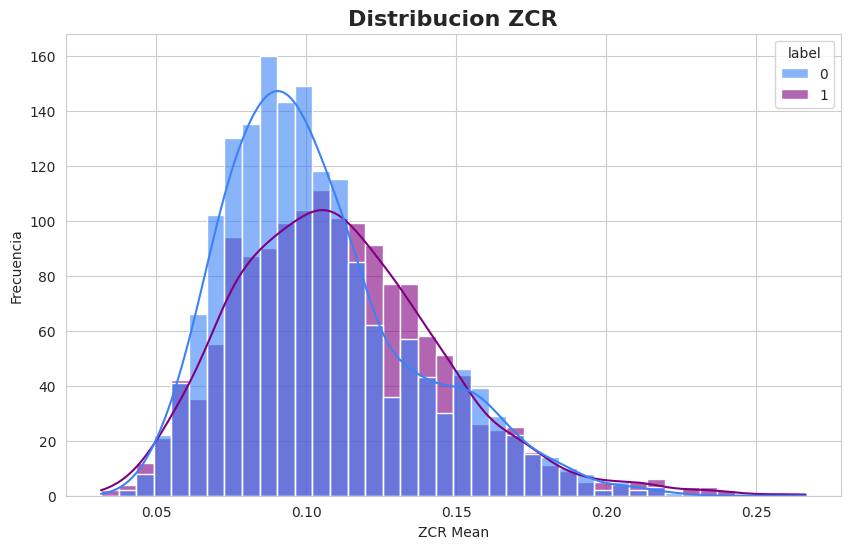

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_unified,
    x="zcr_mean",
    hue="label",
    kde=True,
    palette=PALETTE,
    alpha=0.6
)

plt.title("Distribucion ZCR", fontsize=16, fontweight="bold")
plt.xlabel("ZCR Mean")
plt.ylabel("Frecuencia")

plt.show()

La gráfica muestra la distribución de ZCR Mean (Zero Crossing Rate), una feature que mide cuántas veces la señal de audio cambia de signo. Esta característica es útil porque refleja la complejidad y variabilidad de la señal, aspectos que pueden diferenciar voces humanas de voces sintéticas.
En los resultados se observa que los audios reales (0) tienden a concentrarse en valores ligeramente más bajos, mientras que los audios generados por IA (1) presentan una distribución desplazada hacia valores mayores de ZCR. Esto sugiere que las voces sintéticas podrían contener patrones de frecuencia o ruido más irregulares.
Sin embargo, existe una superposición considerable entre ambas clases, por lo que el ZCR por sí solo no separa completamente los audios reales y sintéticos, aunque sí aporta información relevante cuando se combina con otras features acústicas.

## 1.4. Boxplot MFCC

/tmp/ipykernel_15154/3702633454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


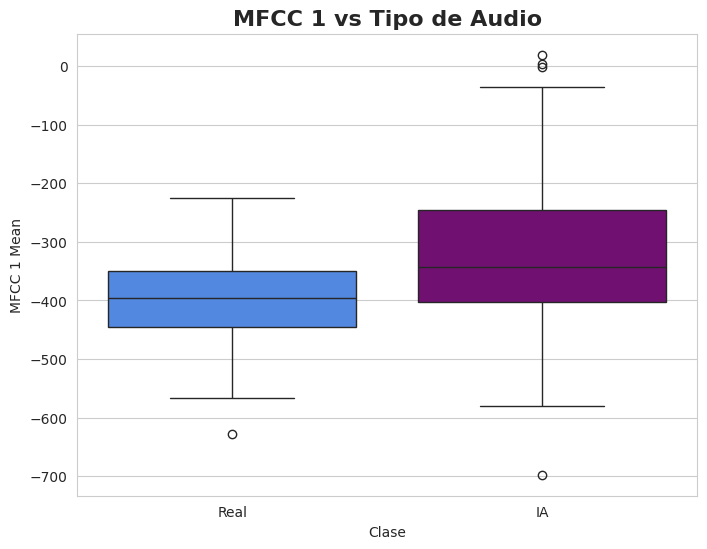

In [13]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_unified,
    x="label",
    y="mfcc_1_mean",
    palette=PALETTE
)

plt.xticks([0,1], ["Real", "IA"])

plt.title("MFCC 1 vs Tipo de Audio", fontsize=16, fontweight="bold")
plt.xlabel("Clase")
plt.ylabel("MFCC 1 Mean")

plt.show()

La gráfica compara la distribución de MFCC 1 Mean entre audios reales y generados por IA. Los MFCC (Mel Frequency Cepstral Coefficients) son una de las features más utilizadas en procesamiento de audio, ya que representan características espectrales relacionadas con la forma y el timbre de la voz.

En este caso, se observa que los audios sintéticos (IA) presentan una mayor dispersión y valores generalmente más altos que los audios reales. Por otro lado, las voces reales muestran una distribución más concentrada.

Esto sugiere que el primer coeficiente MFCC está capturando diferencias acústicas relevantes entre ambos tipos de audio, posiblemente relacionadas con patrones espectrales más artificiales en las voces sintetizadas. Aun así, existe superposición entre clases, por lo que esta feature debe complementarse con otras para mejorar la capacidad de detección.

## 1.5. Boxplot RMS (Outliers)

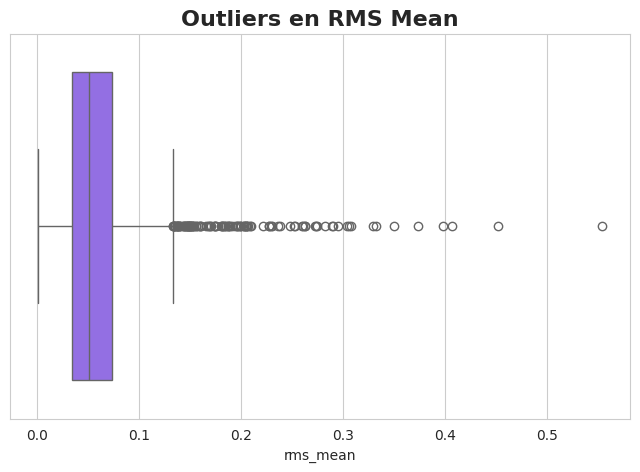

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_unified["rms_mean"],
    color="#8B5CF6"
)

plt.title("Outliers en RMS Mean", fontsize=16, fontweight="bold")

plt.show()

La gráfica muestra los outliers presentes en la feature RMS Mean, que representa la energía promedio del audio. Este análisis se realiza para identificar valores extremos que podrían corresponder a audios atípicos, grabaciones con demasiado ruido, silencios o diferencias de volumen muy marcadas.

Se observa que la mayoría de los audios se concentran en valores bajos de RMS, mientras que existen varios outliers con niveles de energía considerablemente más altos. Esto indica que algunos audios presentan características acústicas muy diferentes al resto del dataset.

Detectar estos outliers es importante porque pueden afectar el entrenamiento del modelo, haciendo que aprenda patrones relacionados con volumen o calidad de grabación en lugar de enfocarse únicamente en las diferencias entre voces reales y sintéticas.

## 1.6. Boxplot RMS (Outliers)

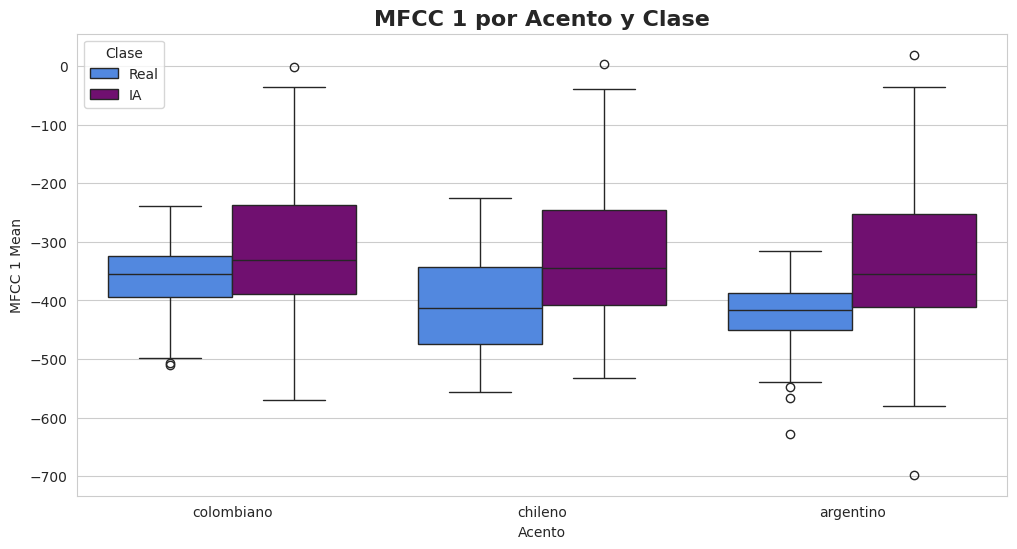

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_unified,
    x="accent",
    y="mfcc_1_mean",
    hue="label",
    palette=PALETTE
)

plt.title("MFCC 1 por Acento y Clase", fontsize=16, fontweight="bold")
plt.xlabel("Acento")
plt.ylabel("MFCC 1 Mean")

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Real", "IA"], title="Clase")

plt.show()

La gráfica compara la distribución de MFCC 1 Mean según el acento y el tipo de audio (real o IA). Este análisis permite verificar si las diferencias observadas provienen realmente de la síntesis de voz o si el modelo podría estar aprendiendo patrones asociados al acento.
En los tres acentos se observa una tendencia similar: los audios generados por IA presentan una mayor dispersión y valores más altos de MFCC 1 en comparación con los audios reales. Esto indica que la feature logra capturar diferencias relacionadas con la generación sintética de voz de manera relativamente consistente entre acentos.
Sin embargo, también existen diferencias entre colombiano, chileno y argentino, lo que confirma que el acento influye en las características acústicas del dataset. Por ello, es importante considerar esta variable durante el entrenamiento y evaluación del modelo para evitar sesgos y asegurar que el sistema aprenda a detectar síntesis de voz y no únicamente diferencias de pronunciación o entonación.

## 1.7. PCA Visualization

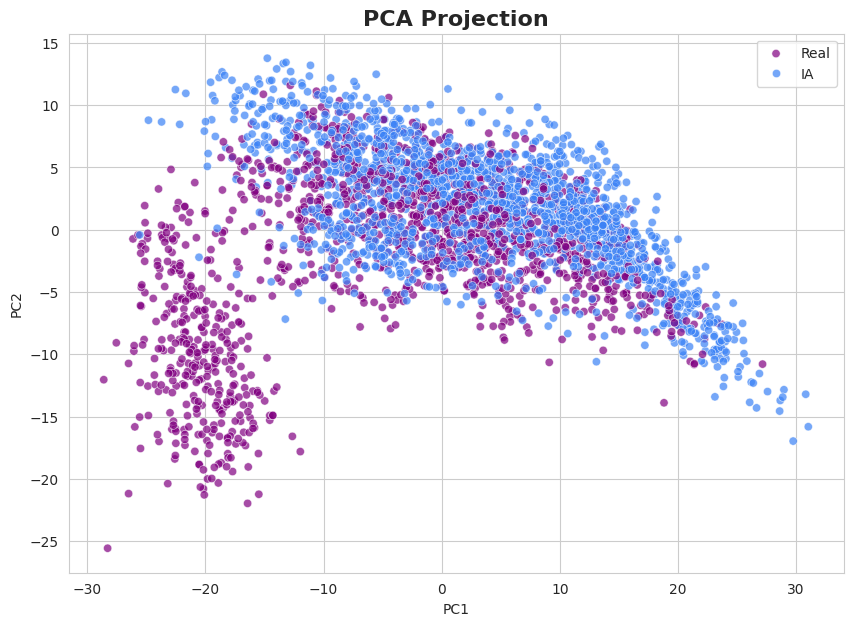

In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = df_unified.select_dtypes(include=['float64', 'int64'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["label"] = df_unified["label"]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="label",
    palette=PALETTE,
    alpha=0.7
)

plt.title("PCA Projection", fontsize=16, fontweight="bold")

plt.legend(labels=["Real", "IA"])

plt.show()

La visualización PCA permite reducir todas las features acústicas del dataset a dos componentes principales (PC1 y PC2) para observar de forma gráfica cómo se distribuyen los audios reales y sintéticos. Este análisis es útil para identificar si las features extraídas contienen información suficiente para diferenciar ambas clases.
En el gráfico se observa una separación parcial entre los audios reales y los generados por IA. Los audios sintéticos presentan una mayor concentración en ciertas regiones del espacio, mientras que los audios reales muestran agrupaciones más dispersas, especialmente en la zona izquierda inferior del gráfico.
Sin embargo, también existe una superposición considerable entre ambas clases, lo que indica que algunas voces sintéticas comparten características acústicas similares a las voces reales. Esto sugiere que las features utilizadas sí capturan diferencias relevantes, aunque no son suficientes para lograr una separación perfecta por sí solas.

## 1.8. PCA por acento

<Axes: xlabel='PC1', ylabel='PC2'>

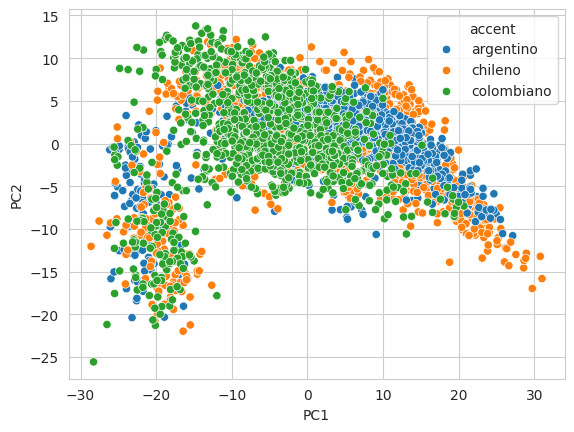

In [21]:
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=df_unified["accent"]
)

En el gráfico se observa que los acentos presentan ciertas agrupaciones y tendencias dentro del espacio generado por PCA, especialmente en algunas regiones donde predomina un acento sobre los demás. Esto indica que las features utilizadas, como MFCC y características espectrales, también capturan información relacionada con la pronunciación y entonación propias de cada país.

Sin embargo, los grupos no están completamente separados y existe bastante superposición entre ellos, lo que sugiere que el dataset mantiene cierta diversidad y no depende únicamente del acento. Aun así, este resultado confirma la importancia de considerar la variable de acento durante el entrenamiento y evaluación del modelo para evitar sesgos y asegurar que el sistema aprenda patrones de síntesis de voz y no únicamente diferencias dialectales.

## 1.9. PCA por genero

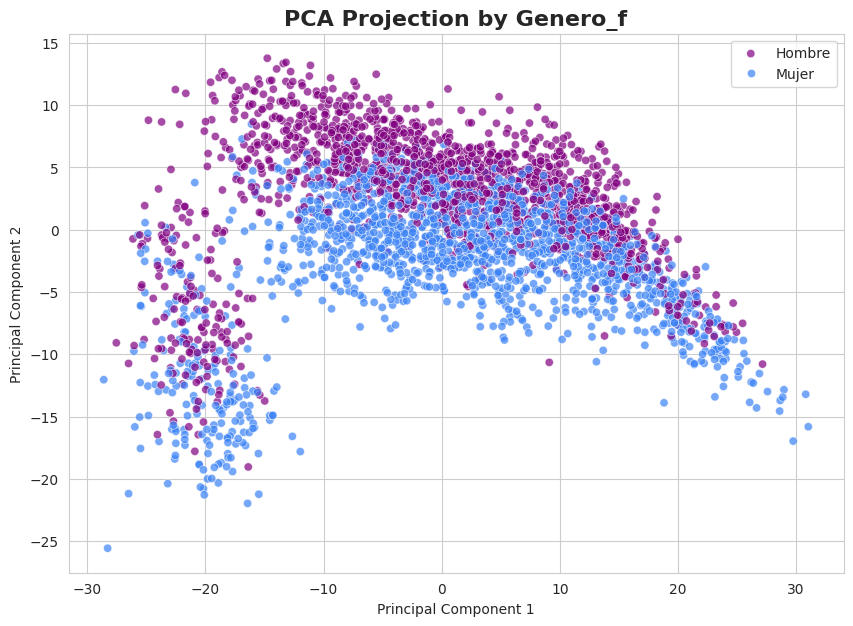

In [22]:
pca_df_genero = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df_genero["genero_f"] = df_unified["genero_f"]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df_genero,
    x="PC1",
    y="PC2",
    hue="genero_f",
    palette=PALETTE,
    alpha=0.7
)

plt.title("PCA Projection by Genero_f", fontsize=16, fontweight="bold")
plt.legend(labels=["Hombre", "Mujer"]) # Assuming 0 for Hombre, 1 for Mujer based on previous usage
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

Hay una separación parcial, con las voces masculinas tendiendo hacia valores mayores del PC2, apesar de ello, los puntos de ambos géneros están en gran medida entremezclados, lo que sugiere que el género por sí solo, no conduce a perfiles acústicos claramente distintos.

## 1.10. Medias de las MFCC por tipo de audio

MFCC 1: La Energía (El volumen)

MFCC 2 al 4: La Forma "Gruesa" (Timbre y Fonemas)
Estos son los más importantes para identificar qué se está diciendo y quién habla. Representan las variaciones de baja frecuencia en el espectro.

MFCC 2: Representa el balance entre frecuencias bajas y altas.

MFCC 3 y 4: Están muy relacionados con los formantes (las resonancias de tu boca al decir letras como la "A" o la "U").

*Los modelos de IA suelen ser muy buenos replicando estos porque son esenciales para que la voz se entienda.*

MFCC 5 al 8: Detalles de Resonancia
Estos capturan cambios más finos en el espectro. Describen matices de la garganta y la posición de la lengua.

*Aquí es donde la IA empieza a tener problemas. A veces, los sintetizadores generan resonancias "metálicas" o demasiado perfectas que se reflejan en estos coeficientes intermedios.*

MFCC 9 al 12: Detalles de Alta Frecuencia (Artefactos de la IA)
Estos representan variaciones muy rápidas y finas en el espectro de frecuencias.

*Capturan texturas sutiles, como el aire al pronunciar una "S" o pequeñas irregularidades en la voz humana. La mayoría de los modelos de IA (especialmente los más antiguos o ligeros) fallan en replicar la complejidad de las altas frecuencias*

In [19]:
mfcc_mean_cols = [col for col in df_unified.columns if col.startswith('mfcc_') and col.endswith('_mean')]

# Group by label and calculate the mean for each MFCC column
mfcc_means_table = df_unified.groupby('label')[mfcc_mean_cols].mean()

# Rename the index for better readability
mfcc_means_table.index = mfcc_means_table.index.map({0: 'Real', 1: 'IA'})

# Transpose the table
mfcc_means_table_transposed = mfcc_means_table.T

# Add a new column with the difference between 'Real' and 'IA' means
mfcc_means_table_transposed['Difference (Real - IA)'] = mfcc_means_table_transposed['Real'] - mfcc_means_table_transposed['IA']

# Add a new column with the percentage difference relative to 'Real'
mfcc_means_table_transposed['Percentage Diff (vs Real)'] = (((mfcc_means_table_transposed['Real'] - mfcc_means_table_transposed['IA']) / mfcc_means_table_transposed['Real']) * 100).map('{:.2f}%'.format)

print("Tabla de Medias de MFCC por Tipo de Audio (Transpuesta con Diferencia y %):")
display(mfcc_means_table_transposed)

Tabla de Medias de MFCC por Tipo de Audio (Transpuesta con Diferencia y %):


label,Real,IA,Difference (Real - IA),Percentage Diff (vs Real)
mfcc_1_mean,-398.225608,-329.292935,-68.932673,17.31%
mfcc_2_mean,66.652032,70.711925,-4.059893,-6.09%
mfcc_3_mean,1.884872,-0.179509,2.064382,109.52%
mfcc_4_mean,17.088867,17.925248,-0.836381,-4.89%
mfcc_5_mean,5.957042,2.573480,3.383562,56.80%
mfcc_6_mean,1.336187,-1.659526,2.995713,224.20%
mfcc_7_mean,-1.557040,-4.342789,2.785749,-178.91%
mfcc_8_mean,-5.247391,-9.025333,3.777942,-72.00%
mfcc_9_mean,-1.670871,-4.008414,2.337544,-139.90%
mfcc_10_mean,-0.466925,-4.739763,4.272838,-915.10%


# 2. Random Forest con Cross Validation

In [24]:
# Eliminamos columnas de metadatos para evitar sesgos o biased
df_model = df_unified.copy()

columnas_a_eliminar = [
    "label",
    "archivo",
    "id_audio",
    "accent",
    "colombiano",
    "chileno",
    "argentino",
    "modelo_cyclegan",
    "modelo_diff",
    "modelo_stargan",
    "modelo_tts_dif",
    "modelo_tts_stargan",
    "modelo_tts",
    "genero_f"
]

X = df_model.drop(columns=columnas_a_eliminar, errors="ignore")

y = df_model["label"]

# Verificar columnas restantes
print("Columnas restantes:")
print(X.columns)

# Ver primeras filas
print("\nPrimeras filas de X:")
display(X.head())

# Ver target
print("\nPrimeras filas de y:")
display(y.head())

Columnas restantes:
Index(['duracion_seg', 'zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max',
       'zcr_median', 'zcr_q1', 'zcr_q3', 'zcr_skew', 'zcr_kurtosis',
       ...
       'rolloff_std', 'rolloff_min', 'rolloff_max', 'rolloff_median',
       'rolloff_q1', 'rolloff_q3', 'rolloff_skew', 'rolloff_kurtosis',
       'rolloff_mode', 'rolloff_iqr'],
      dtype='object', length=575)

Primeras filas de X:


,duracion_seg,zcr_mean,zcr_std,zcr_min,zcr_max,zcr_median,zcr_q1,zcr_q3,zcr_skew,zcr_kurtosis,...,rolloff_std,rolloff_min,rolloff_max,rolloff_median,rolloff_q1,rolloff_q3,rolloff_skew,rolloff_kurtosis,rolloff_mode,rolloff_iqr
0,5.248000,0.087728,0.062789,0.017578,0.342285,0.071289,0.045898,0.102539,1.900573,3.888440,...,1347.354099,617.1875,6789.0625,4070.31250,2609.375000,4632.812500,-0.406286,-0.429953,4609.3750,2023.437500
1,5.504000,0.098413,0.059002,0.022461,0.331543,0.083496,0.057617,0.121094,1.610784,3.025675,...,1203.851692,726.5625,6695.3125,3953.12500,2812.500000,4398.437500,-0.416914,-0.086564,4265.6250,1585.937500
2,5.280000,0.073048,0.055099,0.017090,0.304199,0.059570,0.039795,0.080444,2.238224,5.492080,...,1331.920271,632.8125,6875.0000,3160.15625,2103.515625,4179.687500,0.236749,-0.169685,4179.6875,2076.171875
3,5.504000,0.085156,0.062702,0.014648,0.312500,0.066895,0.039551,0.116211,1.370564,1.903850,...,1385.833931,664.0625,6851.5625,3851.56250,2406.250000,4632.812500,-0.168616,-0.592907,3609.3750,2226.562500
4,5.994937,0.115227,0.090823,0.019043,0.661621,0.101318,0.057495,0.144043,3.240082,14.637935,...,1408.031595,1140.6250,7664.0625,4289.06250,2617.187500,4806.640625,-0.007366,-0.499812,4539.0625,2189.453125



Primeras filas de y:


,label
0,1
1,1
2,1
3,1
4,1


## 2.1. Primer entrenamiendo de Random Forest

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42, #Reproducibilidad
    n_jobs=-1 #Utiliza toda la CPU
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Accuracy por fold:")
print(scores)

print("Accuracy promedio:")
print(np.mean(scores))

print("Desviacion estandar:")
print(np.std(scores))

Accuracy por fold:
[0.96875   0.971875  0.9734375 0.95625   0.9640625]
Accuracy promedio:
0.9668749999999999
Desviacion estandar:
0.006202947887899731


# 3. Crear y entrenar Random Forest con Train/Test Split

In [31]:
# TRAIN / TEST SPLIT
# Se divide el dataset en:
# - entrenamiento (80%)
# - prueba (20%)
#
# stratify=y mantiene balanceadas
# las clases en ambos conjuntos

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Shape Train:")
print(X_train.shape)

print("\nShape Test:")
print(X_test.shape)

Shape Train:
(2560, 575)

Shape Test:
(640, 575)


In [32]:
# RANDOM FOREST
# Se crea el modelo con:

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento del modelo
rf_model.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [33]:
# PREDICCIONES
# El modelo predice las clases
# del conjunto de prueba

y_pred = rf_model.predict(X_test)

print("Predicciones realizadas")

Predicciones realizadas


In [34]:
# CLASSIFICATION REPORT

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       340
           1       0.98      0.97      0.98       300

    accuracy                           0.98       640
   macro avg       0.98      0.98      0.98       640
weighted avg       0.98      0.98      0.98       640



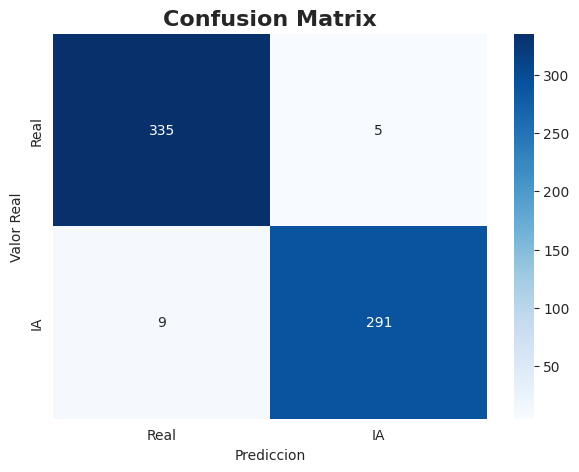

In [35]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Prediccion")
plt.ylabel("Valor Real")

plt.xticks([0.5, 1.5], ["Real", "IA"])
plt.yticks([0.5, 1.5], ["Real", "IA"])

plt.show()

In [36]:
# FEATURE IMPORTANCE

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

print("Top 15 features mas importantes:")

display(feature_importance_df.head(15))

Top 15 features mas importantes:


,feature,importance
536,contrast_6_q1,0.034827
471,bandwidth_q3,0.030946
570,rolloff_q3,0.024416
15,rms_max,0.023044
23,rmse_manual,0.022843
540,contrast_6_mode,0.019716
533,contrast_6_min,0.018527
18,rms_q3,0.015678
13,rms_std,0.014670
27,mfcc_1_min,0.013837


/tmp/ipykernel_15154/521991229.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


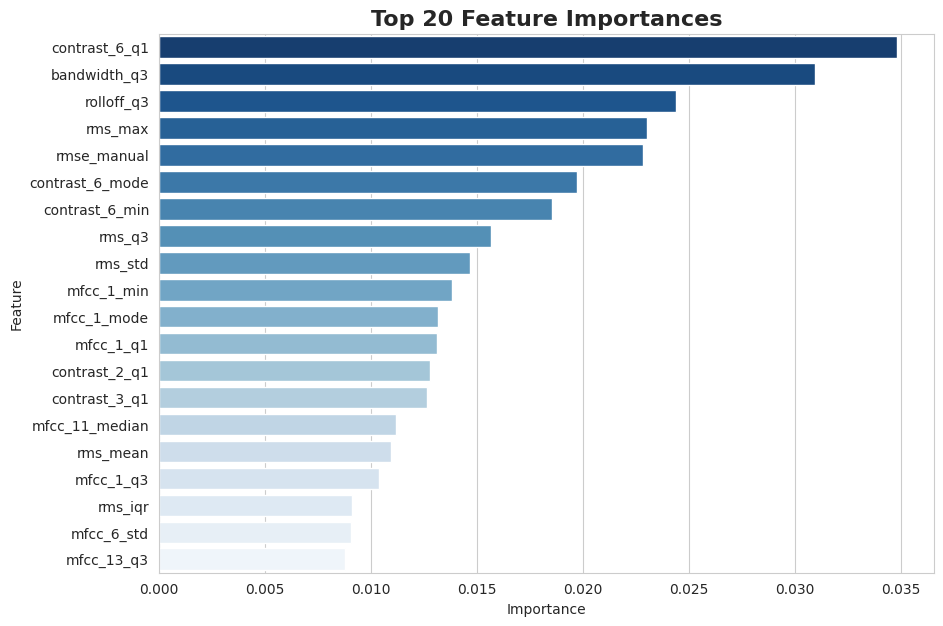

In [37]:
# GRAFICA FEATURE IMPORTANCE

top_features = feature_importance_df.head(20)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    palette="Blues_r"
)

plt.title(
    "Top 20 Feature Importances",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 3.1. Recall por acentos

In [38]:
#Guardamos los acentos antes de eliminar columnas
accent_values = df_model["accent"]

In [39]:
#Hacer el split incluyendo acentos
X_train, X_test, y_train, y_test, accent_train, accent_test = train_test_split(
    X,
    y,
    accent_values,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [53]:
from sklearn.metrics import classification_report

# Crear dataframe auxiliar (Dataset de control)
results_df = pd.DataFrame({
    "accent": accent_test,
    "real_label": y_test,
    "pred_label": y_pred
})

# Evaluar por acento
for accent in results_df["accent"].unique():

    print("\n")
    print(f"Resultados para acento: {accent}")
    print("\n")

    subset = results_df[
        results_df["accent"] == accent
    ]

    report = classification_report(
        subset["real_label"],
        subset["pred_label"]
    )

    print(report)



Resultados para acento: argentino


              precision    recall  f1-score   support

           0       0.96      1.00      0.98       120
           1       1.00      0.95      0.97       101

    accuracy                           0.98       221
   macro avg       0.98      0.98      0.98       221
weighted avg       0.98      0.98      0.98       221



Resultados para acento: chileno


              precision    recall  f1-score   support

           0       0.98      0.96      0.97       106
           1       0.96      0.98      0.97       101

    accuracy                           0.97       207
   macro avg       0.97      0.97      0.97       207
weighted avg       0.97      0.97      0.97       207



Resultados para acento: colombiano


              precision    recall  f1-score   support

           0       0.98      0.99      0.99       114
           1       0.99      0.98      0.98        98

    accuracy                           0.99       212
   macro avg   

In [55]:
#Ajustar Recall por acento

from sklearn.metrics import accuracy_score, classification_report

# 1. Preparación de datos (Asumiendo que df_unified es tu dataframe original)
# Extraemos los acentos ANTES de limpiar X
accent_values = df_unified["accent"]
y = df_unified["label"]

# Eliminamos metadatos de X (lo que ya tenías)
columnas_a_eliminar = [
    "label", "archivo", "id_audio", "accent", "colombiano", "chileno",
    "argentino", "modelo_cyclegan", "modelo_diff", "modelo_stargan",
    "modelo_tts_dif", "modelo_tts_stargan", "modelo_tts", "genero_f"
]
X = df_unified.drop(columns=columnas_a_eliminar, errors="ignore")

# 2. Split Sincronizado (X, y, y ACENTOS)
# Usamos el mismo random_state para consistencia
X_train, X_test, y_train, y_test, accent_train, accent_test = train_test_split(
    X,
    y,
    accent_values,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 3. Entrenamiento del Modelo
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced' # Recomendado para detectar mejor los sintéticos
)
rf_model.fit(X_train, y_train)

# 4. Generación de predicciones
y_pred = rf_model.predict(X_test)

# 5. Análisis de "Discriminación" por Acento
# Creamos un dataframe de resultados solo para el set de prueba
results_df = pd.DataFrame({
    "accent": accent_test,
    "real": y_test,
    "pred": y_pred
})

print("=== ANÁLISIS DE SESGO POR ACENTO ===\n")

# Guardaremos métricas para una tabla final
summary_metrics = []

for accent in results_df["accent"].unique():
    subset = results_df[results_df["accent"] == accent]

    acc = accuracy_score(subset["real"], subset["pred"])

    print(f"--- Acento: {accent} ---")
    print(f"Muestras: {len(subset)}")
    print(classification_report(subset["real"], subset["pred"]))

    summary_metrics.append({
        "Acento": accent,
        "Accuracy": acc,
        "Muestras": len(subset)
    })

# 6. Tabla comparativa rápida
summary_df = pd.DataFrame(summary_metrics).sort_values(by="Accuracy", ascending=False)
print("\n=== RESUMEN COMPARATIVO ===")
print(summary_df.to_string(index=False))

=== ANÁLISIS DE SESGO POR ACENTO ===

--- Acento: argentino ---
Muestras: 221
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       120
           1       1.00      0.96      0.98       101

    accuracy                           0.98       221
   macro avg       0.98      0.98      0.98       221
weighted avg       0.98      0.98      0.98       221

--- Acento: chileno ---
Muestras: 207
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       106
           1       0.95      0.97      0.96       101

    accuracy                           0.96       207
   macro avg       0.96      0.96      0.96       207
weighted avg       0.96      0.96      0.96       207

--- Acento: colombiano ---
Muestras: 212
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       114
           1       0.98      0.98      0.98        98

    accuracy             

## 3.2. Recall por modelo de generacion

## 3.3. Recall por genero